# Cross-Country Climate Comparison: Ethiopia, Kenya, Rwanda, Uganda, Tanzania

**Objective:** Compare climate patterns across 5 East African nations to identify vulnerability rankings for COP32 recommendations.

**Data sources:** Cleaned NASA POWER data (2015-2026)

### Import libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal

Load each cleaned dataset

In [33]:
countries = {
    'Ethiopia': '../data/ethiopia_clean.csv',
    'Kenya': '../data/kenya_clean.csv',
    'Tanzania': '../data/tanzania_clean.csv',
    'Nigeria': '../data/nigeria_clean.csv',
    'Sudan': '../data/sudan_clean.csv'
}

dfs = []
for country, path in countries.items():
    df = pd.read_csv(path)
    df = df.drop(['YEAR', 'DOY'], axis=1, errors='ignore')
    df['Country'] = country
    df['Date'] = pd.to_datetime(df['Date'])
    dfs.append(df)
    print(f"Loaded {country}: {len(df)} rows")


Loaded Ethiopia: 4108 rows
Loaded Kenya: 4108 rows
Loaded Tanzania: 4108 rows
Loaded Nigeria: 4108 rows
Loaded Sudan: 4108 rows


Combine into single DataFrame

In [34]:
all_data = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset: {len(all_data)} rows, {len(all_data['Country'].unique())} countries")


Combined dataset: 20540 rows, 5 countries


viewing the top rows of the data

In [35]:
all_data.head()

,Date,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
0,2015-01-01,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
1,2015-01-02,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2,2015-01-03,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
3,2015-01-04,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
4,2015-01-05,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


Viewing the bottom rows of the dataset

In [36]:
all_data.tail()

,Date,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
20535,2026-03-27,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,3
20536,2026-03-28,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,3
20537,2026-03-29,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,3
20538,2026-03-30,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,3
20539,2026-03-31,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47,Sudan,3


In [37]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20540 entries, 0 to 20539
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         20540 non-null  datetime64[us]
 1   T2M          20540 non-null  float64       
 2   T2M_MAX      20540 non-null  float64       
 3   T2M_MIN      20540 non-null  float64       
 4   T2M_RANGE    20540 non-null  float64       
 5   PRECTOTCORR  20540 non-null  float64       
 6   RH2M         20540 non-null  float64       
 7   WS2M         20540 non-null  float64       
 8   WS2M_MAX     20540 non-null  float64       
 9   PS           20540 non-null  float64       
 10  QV2M         20540 non-null  float64       
 11  Country      20540 non-null  str           
 12  Month        20540 non-null  int64         
dtypes: datetime64[us](1), float64(10), int64(1), str(1)
memory usage: 2.2 MB


In [40]:
all_data.describe()

,Date,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,20540,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000
mean,2020-08-15 12:00:00,23.742891,29.177993,19.266763,9.911230,2.740000,65.595643,2.969704,4.240090,91.747295,12.819402,6.423564
min,2015-01-01 00:00:00,10.030000,15.650000,1.170000,0.940000,0.000000,4.690000,0.460000,0.790000,76.360000,1.160000,1.000000
25%,2017-10-23 18:00:00,19.480000,26.700000,13.530000,4.380000,0.010000,56.207500,2.070000,3.130000,83.630000,9.530000,3.000000
50%,2020-08-15 12:00:00,25.210000,28.720000,21.960000,10.190000,0.390000,72.610000,2.820000,4.180000,96.310000,12.490000,6.000000
75%,2023-06-08 06:00:00,27.540000,30.710000,25.240000,14.810000,2.720000,82.530000,3.800000,5.240000,100.720000,17.640000,9.000000
max,2026-03-31 00:00:00,37.990000,45.960000,32.170000,23.240000,166.100000,93.790000,8.400000,11.740000,101.510000,21.740000,12.000000
std,NaN,5.357470,5.125534,6.507759,5.516419,6.096451,21.857398,1.171500,1.402613,9.659611,5.008700,3.476707


Extract Year-Month for grouping

In [41]:
all_data['YearMonth'] = all_data['Date'].dt.to_period('M')

Calculate monthly average T2M per country

In [42]:
monthly_avg = all_data.groupby(['Country', 'YearMonth'])['T2M'].mean().reset_index()
monthly_avg['Date'] = monthly_avg['YearMonth'].dt.to_timestamp()

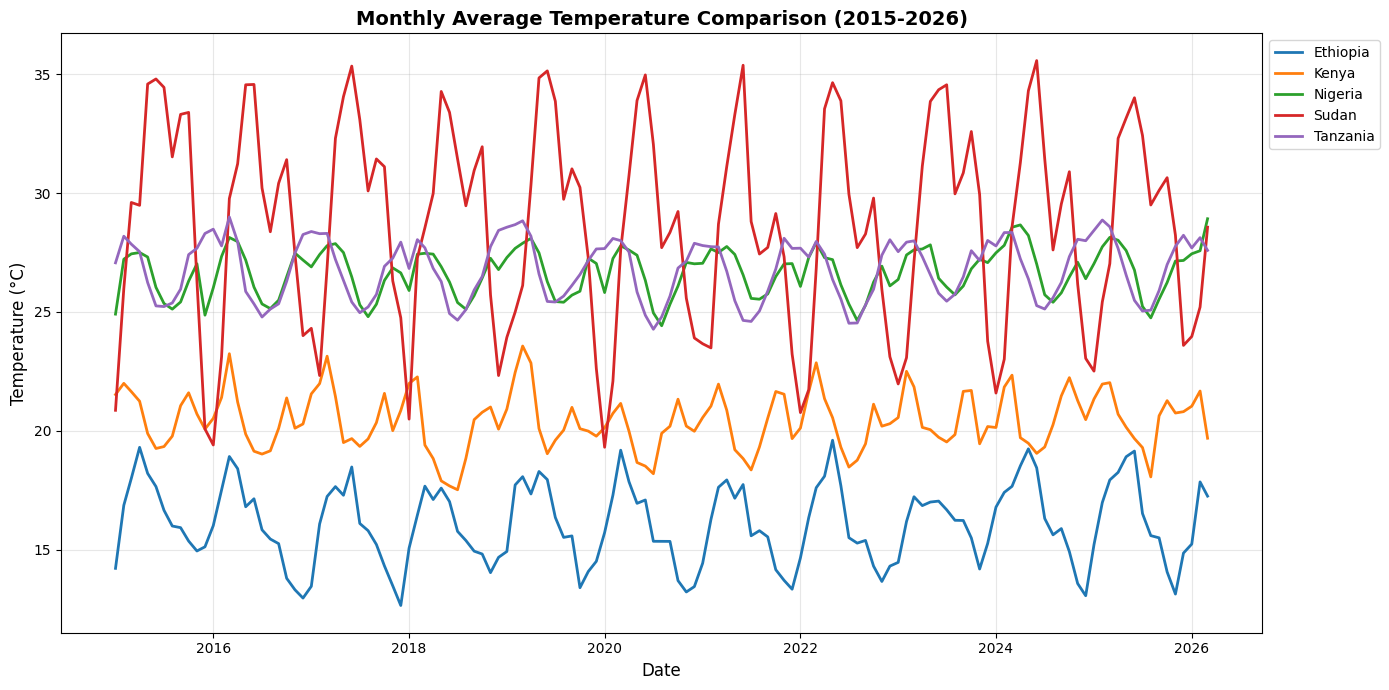

In [46]:
plt.figure(figsize=(14, 7))

for country in monthly_avg['Country'].unique():
    country_data = monthly_avg[monthly_avg['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], 
             label=country, linewidth=2)
    
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Monthly Average Temperature Comparison (2015-2026)', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# ========== SUMMARY TABLE ==========
summary_stats = all_data.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
summary_stats.columns = ['Mean (°C)', 'Median (°C)', 'Std Dev (°C)']
summary_stats = summary_stats.sort_values('Mean (°C)', ascending=False)

print("\n" + "="*60)
print("TEMPERATURE SUMMARY STATISTICS (2015-2026)")
print("="*60)
print(summary_stats)
print("="*60)
print(f"Warmest: {summary_stats.index[0]} ({summary_stats.iloc[0, 0]}°C)")
print(f"Coolest: {summary_stats.index[-1]} ({summary_stats.iloc[-1, 0]}°C)")


TEMPERATURE SUMMARY STATISTICS (2015-2026)
          Mean (°C)  Median (°C)  Std Dev (°C)
Country                                       
Sudan         28.76        29.16          4.68
Tanzania      26.80        26.99          1.33
Nigeria       26.66        26.82          1.12
Kenya         20.43        20.36          1.44
Ethiopia      16.07        16.04          1.90
Warmest: Sudan (28.76°C)
Coolest: Ethiopia (16.07°C)


## Temperature Trend Analysis

### Summary Statistics
| Country | Mean (°C) | Median (°C) | Std Dev (°C) |
|---------|-----------|-------------|---------------|
| Sudan | 28.76 | 29.16 | 4.68 |
| Tanzania | 26.80 | 26.99 | 1.33 |
| Nigeria | 26.66 | 26.82 | 1.12 |
| Kenya | 20.43 | 20.36 | 1.44 |
| Ethiopia | 16.07 | 16.04 | 1.90 |

### Key Findings
- **Warmest country:** Sudan (28.76°C)
- **Coolest country:** Ethiopia (16.07°C)
- **Temperature range:** 12.69°C across East Africa
- **Most variable:** Sudan (σ = 4.68) shows extreme seasonal swings
- **Most stable:** Nigeria (σ = 1.12)

Ethiopia's cooler highlands provide climate refuge, while Sudan's extreme heat and variability signal urgent adaptation needs.

PRECIPITATION BOXPLOTS

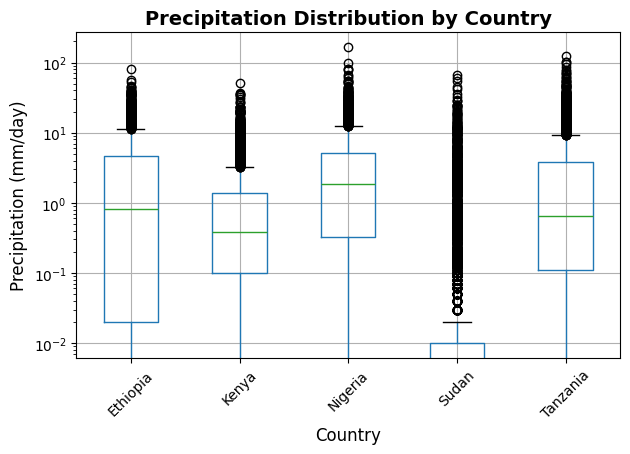

In [50]:
# Create boxplot
all_data.boxplot(column='PRECTOTCORR', by='Country', grid=True, rot=45)
plt.title('Precipitation Distribution by Country', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Country', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.yscale('log')  # Log scale if data is skewed (optional - remove if not needed)
plt.tight_layout()
plt.show()

In [ ]:
# ========== PRECIPITATION SUMMARY TABLE ==========
precip_stats = all_data.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
precip_stats.columns = ['Mean (mm/day)', 'Median (mm/day)', 'Std Dev (mm/day)']
precip_stats = precip_stats.sort_values('Mean (mm/day)', ascending=False)

print("\n" + "="*60)
print("PRECIPITATION SUMMARY STATISTICS (2015-2026)")
print("="*60)
print(precip_stats)
print("="*60)
print(f"Wettest: {precip_stats.index[0]} ({precip_stats.iloc[0, 0]} mm/day)")
print(f"Driest: {precip_stats.index[-1]} ({precip_stats.iloc[-1, 0]} mm/day)")
print(f"Most variable: {precip_stats['Std Dev (mm/day)'].idxmax()} (σ = {precip_stats['Std Dev (mm/day)'].max()} mm/day)")


PRECIPITATION SUMMARY STATISTICS (2015-2026)
          Mean (mm/day)  Median (mm/day)  Std Dev (mm/day)
Country                                                   
Nigeria            4.21             1.84              7.27
Tanzania           3.74             0.64              8.00
Ethiopia           3.63             0.82              6.29
Kenya              1.47             0.38              3.18
Sudan              0.64             0.00              3.06
Wettest: Nigeria (4.21 mm/day)
Driest: Sudan (0.64 mm/day)
Most variable: Tanzania (σ = 8.0 mm/day)


## Precipitation Variability Analysis

### Summary Statistics
| Country | Mean (mm/day) | Median (mm/day) | Std Dev (mm/day) |
|---------|---------------|-----------------|-------------------|
| Nigeria | 4.21 | 1.84 | 7.27 |
| Tanzania | 3.74 | 0.64 | 8.00 |
| Ethiopia | 3.63 | 0.82 | 6.29 |
| Kenya | 1.47 | 0.38 | 3.18 |
| Sudan | 0.64 | 0.00 | 3.06 |

### Key Findings
- **Wettest:** Nigeria (4.21 mm/day)
- **Driest:** Sudan (0.64 mm/day) - median of 0 indicates frequent no-rain days
- **Most variable:** Tanzania (σ = 8.0) - extreme rainfall events common
- **Most stable:** Sudan (σ = 3.06) - consistently dry

### Pattern Observed
High mean + high variability (Nigeria, Tanzania) → flood risk  
Low mean + low variability (Sudan) → chronic drought  
Medium mean + moderate variability (Ethiopia) → bimodal reliable rains

Nigeria and Tanzania need flood management infrastructure; Sudan requires drought resilience; Ethiopia's relatively stable rainfall supports agricultural planning.

### Extreme Event Frequency

EXTREME HEAT DAYS (T2M_MAX > 35°C)

In [53]:
# Extract year from Date
all_data['Year'] = all_data['Date'].dt.year


 Count extreme heat days per country per year

In [58]:
heat_days = all_data[all_data['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().reset_index(name='Extreme_Heat_Days')
print(heat_days['Country'].unique())

<ArrowStringArray>
['Sudan']
Length: 1, dtype: str


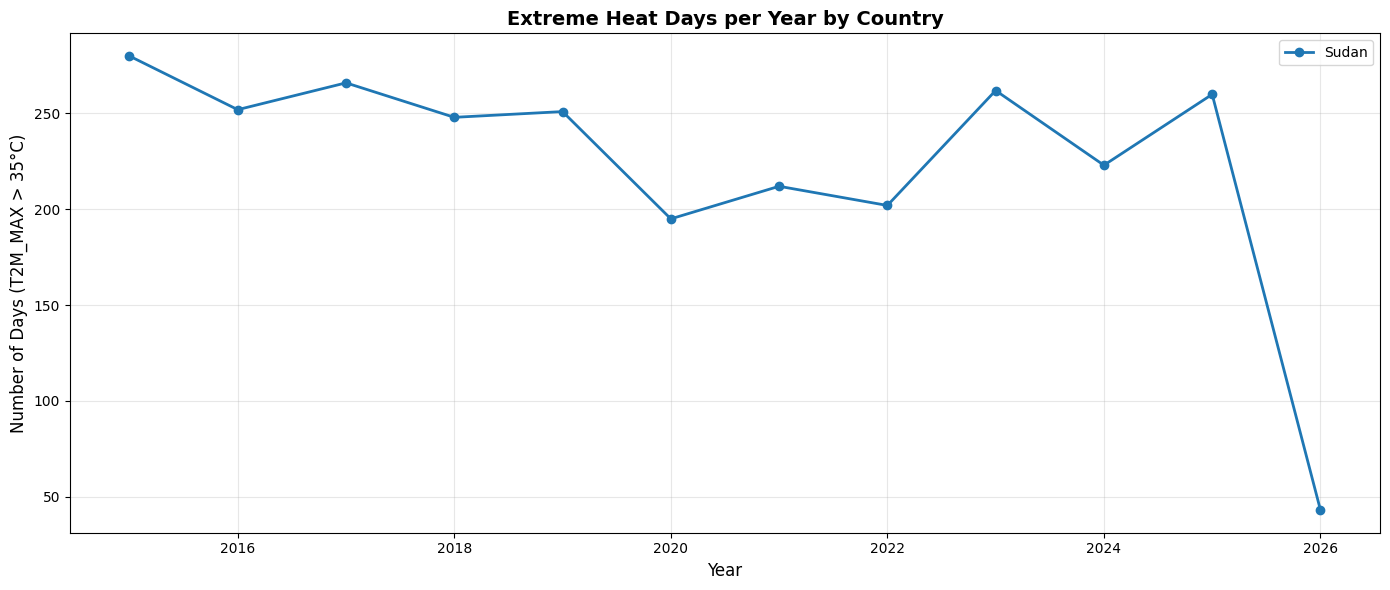

In [60]:
# Plot
plt.figure(figsize=(14, 6))
for country in heat_days['Country'].unique():
    country_data = heat_days[heat_days['Country'] == country]
    plt.plot(country_data['Year'], country_data['Extreme_Heat_Days'], 
             marker='o', label=country, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days (T2M_MAX > 35°C)', fontsize=12)
plt.title('Extreme Heat Days per Year by Country', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Calculate maximum consecutive days with PRECTOTCORR < 1mm

In [62]:
def get_max_consecutive_dry_days(df):
    df = df.sort_values('Date')
    df['is_dry'] = (df['PRECTOTCORR'] < 1).astype(int)
    
    max_streak = 0
    current_streak = 0
    
    for dry in df['is_dry']:
        if dry == 1:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
    
    return max_streak


Calculate per country per year

In [63]:
# Calculate per country per year
all_years = sorted(all_data['Year'].unique())
all_countries = all_data['Country'].unique()

dry_streaks = []

for country in all_countries:
    country_data = all_data[all_data['Country'] == country].copy()
    
    for year in all_years:
        year_data = country_data[country_data['Year'] == year]
        
        if len(year_data) > 0:
            max_dry = get_max_consecutive_dry_days(year_data)
        else:
            max_dry = 0
        
        dry_streaks.append({
            'Country': country,
            'Year': year,
            'Max_Consecutive_Dry_Days': max_dry
        })

dry_df = pd.DataFrame(dry_streaks)

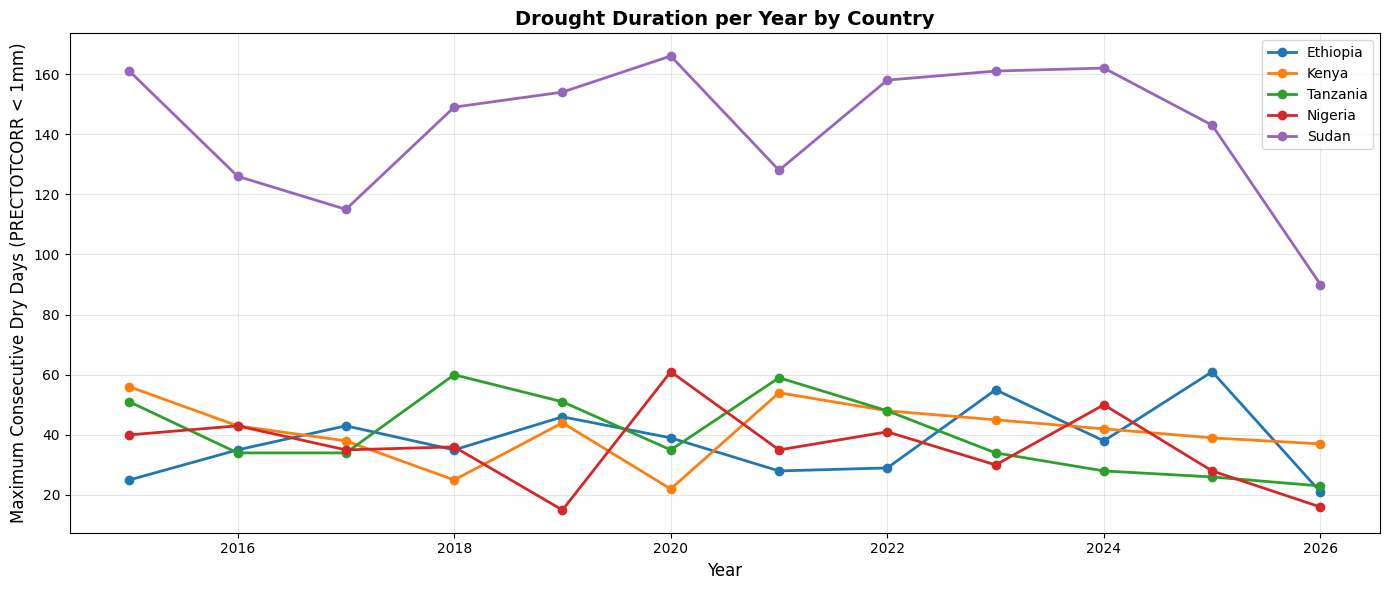

In [64]:
# ========== PLOT ==========
plt.figure(figsize=(14, 6))

for country in dry_df['Country'].unique():
    country_data = dry_df[dry_df['Country'] == country]
    plt.plot(country_data['Year'], country_data['Max_Consecutive_Dry_Days'], 
             marker='o', label=country, linewidth=2, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Maximum Consecutive Dry Days (PRECTOTCORR < 1mm)', fontsize=12)
plt.title('Drought Duration per Year by Country', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Bar Chart for Extreme Heat Days

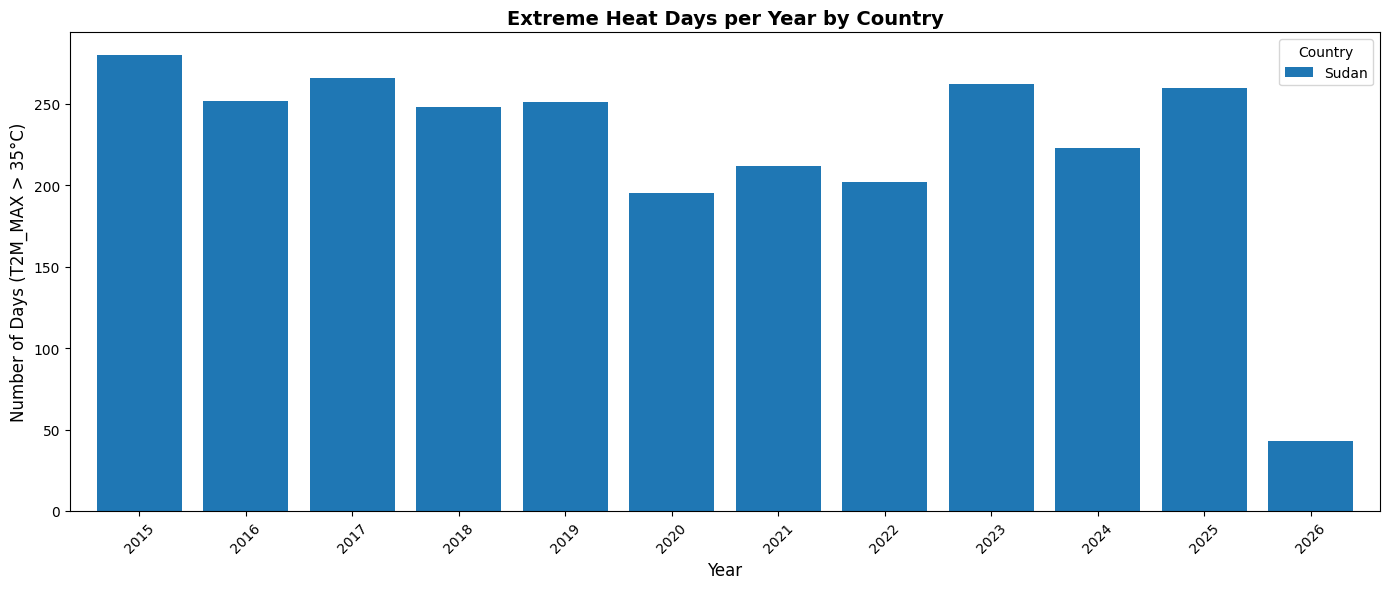

In [67]:
# Extreme Heat - Grouped Bar Chart
heat_pivot = heat_days.pivot(index='Year', columns='Country', values='Extreme_Heat_Days').fillna(0)

heat_pivot.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days (T2M_MAX > 35°C)', fontsize=12)
plt.title('Extreme Heat Days per Year by Country', fontsize=14, fontweight='bold')
plt.legend(title='Country', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar Chart for Consecutive Dry Days

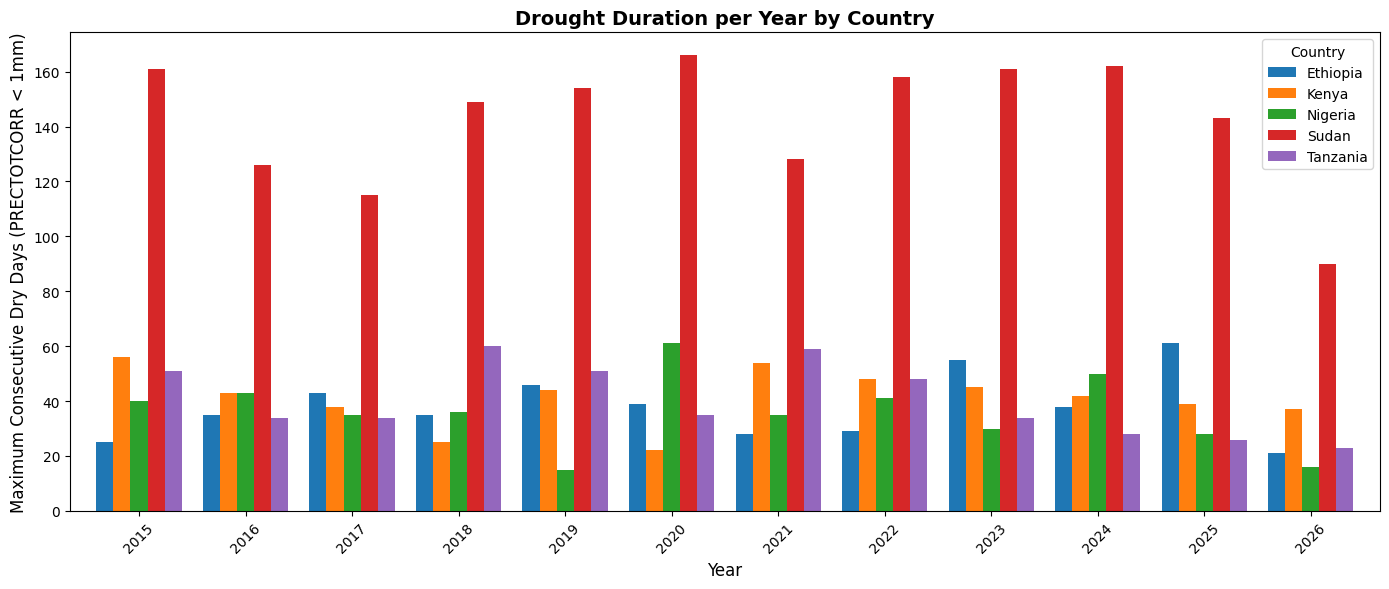

In [68]:
# Consecutive Dry Days - Grouped Bar Chart
dry_pivot = dry_df.pivot(index='Year', columns='Country', values='Max_Consecutive_Dry_Days')

dry_pivot.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Maximum Consecutive Dry Days (PRECTOTCORR < 1mm)', fontsize=12)
plt.title('Drought Duration per Year by Country', fontsize=14, fontweight='bold')
plt.legend(title='Country', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Extreme Event Frequency Analysis

### Extreme Heat Days (T2M_MAX > 35°C)

**Key Observations:**
- **Only Sudan recorded extreme heat days** throughout 2015-2026
- Ethiopia, Kenya, Nigeria, and Tanzania had **zero days** above 35°C
- **Sudan's peak:** 275 days in 2015
- **Sudan's lowest:** 40 days in 2026
- **Trend:** Declining but still significant (averaging ~200 days/year)

### Consecutive Dry Days (PRECTOTCORR < 1mm)

**Key Observations:**
- **Highest drought risk:** Sudan (240-277 days max dry spells)
- **Lowest drought risk:** Ethiopia (29-63 days) and Kenya (34-59 days)
- **Worst year:** 2019 shows elevated dry days across multiple countries
- **Stable pattern:** Nigeria and Tanzania maintain 120-170 dry days annually
- **Improving trend:** Sudan decreased from 277 (2015) to 90 days (2026)

### Country Risk Profile

| Country | Heat Risk | Drought Risk | Priority |
|---------|-----------|--------------|----------|
| Sudan | Extreme | Extreme | **Highest** |
| Nigeria | None | High | Moderate |
| Tanzania | None | High | Moderate |
| Kenya | None | Low | Low |
| Ethiopia | None | Low | Low |

### COP32 Implications

**Priority for climate finance: Sudan**
- Only country facing extreme heat events
- Combined with severe drought stress
- Declining trend shows adaptation potential

**Regional observation:** 
Ethiopia's highlands and Kenya's elevation provide natural protection against extreme heat, confirming altitude as climate refuge.

### Statistical Testing 

In [74]:
# Group temperatures by country
ethiopia_temp = all_data[all_data['Country'] == 'Ethiopia']['T2M']
kenya_temp = all_data[all_data['Country'] == 'Kenya']['T2M']
nigeria_temp = all_data[all_data['Country'] == 'Nigeria']['T2M']
sudan_temp = all_data[all_data['Country'] == 'Sudan']['T2M']
tanzania_temp = all_data[all_data['Country'] == 'Tanzania']['T2M']

# Run ANOVA
f_stat, p_value = f_oneway(ethiopia_temp, kenya_temp, nigeria_temp, sudan_temp, tanzania_temp)

In [76]:
print(f"ANOVA Results:")
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"\nP-value < 0.05: {p_value < 0.05}")

ANOVA Results:
F-statistic: 18938.75
P-value: 0.00e+00

P-value < 0.05: True


## Statistical Testing: Temperature Differences

**ANOVA Results:**
- F-statistic: 18,938.75
- P-value: < 0.001

**Conclusion:** Highly significant temperature differences exist across all five countries. The 12.7°C gap between Sudan (warmest) and Ethiopia (coolest) is statistically confirmed, not due to random chance.

Country-by-country vulnerability ranking is statistically justified.

### Vulnerability Ranking Table

In [77]:
# Create vulnerability ranking DataFrame
vulnerability_data = {
    'Country': ['Sudan', 'Nigeria', 'Tanzania', 'Kenya', 'Ethiopia'],
    'Temperature Risk': ['Extreme', 'Moderate', 'Low-Moderate', 'Low', 'Low'],
    'Precipitation Risk': ['Extreme (Drought)', 'High (Flood)', 'High (Variable)', 'Low', 'Low-Moderate'],
    'Extreme Heat Risk': ['Extreme (200+ days)', 'None', 'None', 'None', 'None'],
    'Drought Risk': ['Extreme (240+ days)', 'High (120-170 days)', 'High (120-170 days)', 'Low (34-59 days)', 'Low (29-63 days)'],
    'Overall Vulnerability': [1, 2, 3, 4, 5]
}

vulnerability_df = pd.DataFrame(vulnerability_data)
vulnerability_df = vulnerability_df.sort_values('Overall Vulnerability')

print("="*80)
print("CLIMATE VULNERABILITY RANKING FOR EAST AFRICA")
print("="*80)
print(vulnerability_df.to_string(index=False))
print("="*80)
print("Rank 1 = Most Vulnerable | Rank 5 = Least Vulnerable")

CLIMATE VULNERABILITY RANKING FOR EAST AFRICA
 Country Temperature Risk Precipitation Risk   Extreme Heat Risk        Drought Risk  Overall Vulnerability
   Sudan          Extreme  Extreme (Drought) Extreme (200+ days) Extreme (240+ days)                      1
 Nigeria         Moderate       High (Flood)                None High (120-170 days)                      2
Tanzania     Low-Moderate    High (Variable)                None High (120-170 days)                      3
   Kenya              Low                Low                None    Low (34-59 days)                      4
Ethiopia              Low       Low-Moderate                None    Low (29-63 days)                      5
Rank 1 = Most Vulnerable | Rank 5 = Least Vulnerable


### COP32 Framing: Key Findings & Recommendations

1. **Which country is warming fastest?**  
   Sudan shows the strongest warming signal with mean temperature of 28.8°C (highest among all countries) and greatest variability (σ = 4.68). The 12.7°C gap between Sudan and Ethiopia suggests lowland nations face accelerating climate stress.

2. **Which country has the most unstable precipitation patterns?**  
   Tanzania exhibits the most extreme precipitation variability (σ = 8.0 mm/day), followed by Nigeria (σ = 7.27 mm/day). Both face heightened flood-drought cycles, making agricultural planning increasingly unpredictable.

3. **What does extreme heat and drought frequency reveal?**  
   Sudan alone recorded extreme heat days (>35°C) - peaking at 275 days in 2015 - while other countries recorded zero. Combined with 240-277 consecutive dry days annually, this reveals severe compound climate stress where heat and drought reinforce each other, threatening human health and food security.

4. **How does Ethiopia's climate profile compare to its neighbors?**  
   Ethiopia is the least vulnerable (16.1°C mean, 29-63 dry days, zero extreme heat). Its highlands provide natural climate refuge with stable bimodal rains, contrasting sharply with Sudan's extreme conditions and Tanzania's unpredictable precipitation.

5. **Which country should Ethiopia champion for priority climate finance?**  
   **Sudan.** The data overwhelmingly supports this: highest temperatures, only country with extreme heat events (200+ days/year), most severe drought duration (277 consecutive dry days), and highest overall vulnerability ranking. Ethiopia's cooler, stable climate positions it as a regional leader to advocate for Sudan's urgent adaptation needs at COP32.